## 분석 주제
**배송 지연 예측 기반 고객 만족도 관리 시스템**

## 주요 질문
**"배송 서비스 품질을 높여서 고객 만족도 관리를 할 수 있을까?"**

## 세부 질문
**상품 특성(무게/카테고리)가 배송지연일수에 영향을 미칠까?"**
- 배송지연일수는 양수인 주문건만 확인한다.

In [218]:
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import numpy as np

from scipy import stats
from scipy.stats import skew, kurtosis

import scikit_posthocs as sp

from unidecode import unidecode
import geopandas as gpd
import sys
import os

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None) # 모든 컬럼이 다 보인다.
pd.set_option('display.max_rows', 100) # 행 출력 개수 제한

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [219]:
# 데이터 로드 & 정제

all = pd.read_csv('../data/olist_preprocess_ver2_data.csv')
df= all.copy()
# print(df.shape[0], 'rows × ', df.shape[1], 'columns')
# 111495 rows ×  29 columns

# 날짜 칼럼 변환
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date',
    'review_creation_date'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df = df[
    (df['order_delivered_customer_date'] != pd.Timestamp('2099-01-01')) &  #두 조건 동일행 의미
    (df['order_status'] == 'delivered')
]
# removed rows: 1881
# remaining rows: 10961

In [220]:
# 배송 지연 계산 (핵심 타겟)
# 배송 지연 일수 계산
df['delivery_delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['is_delayed'] = (df['delivery_delay_days'] > 0).astype(int)

In [221]:
# 필요한 컬럼만 뽑아보자
product_column = ['product_id', 'product_category_name_english','product_weight_g',
                  'product_length_cm','product_height_cm','product_width_cm',
                  'delivery_delay_days','is_delayed']

# df_product = df[product_column].copy()
df_delayed = df[product_column].copy()

# 지연된 주문건만 필터링
df_product = df_delayed[df_delayed['delivery_delay_days'] > 0].copy()

In [222]:
df_product

,product_id,product_category_name_english,product_weight_g,product_length_cm,product_height_cm,product_width_cm,delivery_delay_days,is_delayed
19,5ac9d9e379c606e36a8094a6046f75dc,health_beauty,525.0,21.0,16.0,13.0,11,1
24,7b717060aa783eb7f23a747a3a733dd7,cool_stuff,500.0,16.0,12.0,22.0,9,1
41,be021417a6acb56b9b50d3fd2714baa8,housewares,14300.0,38.0,34.0,34.0,7,1
58,b37b72d5a56f887725c2862184b8cab8,telephony,150.0,19.0,4.0,11.0,1,1
59,b37b72d5a56f887725c2862184b8cab8,telephony,150.0,19.0,4.0,11.0,1,1
...,...,...,...,...,...,...,...,...
111448,4f18ca9862f511ecba98258b2194d061,furniture_bedroom,12500.0,43.0,33.0,33.0,5,1
111449,149de4383ccb1829ea75380fc5f0b5fa,health_beauty,750.0,18.0,19.0,23.0,3,1
111475,014a8a503291921f7b004a5215bb3c36,baby,150.0,16.0,7.0,11.0,21,1
111477,58efb9b638561ce132216a9a612513e2,furniture_living_room,9700.0,27.0,15.0,92.0,2,1


# 가설 설정
### 1. 무게 (연속형)
- 귀무가설 : "상품의 무게는 배송지연에 영향을 미치지 않는다."
- 대립가설 : "상품의 무게는 배송지연에 영향을 미친다."
### 2. 부피 (연속형)
- 귀무가설 : "상품의 부피는 배송지연에 영향을 미치지 않는다."
- 대립가설 : "상품의 부피는 배송지연에 영향을 미친다."
### 3. 카테고리 (범주형)
- 귀무가설 : "상품의 카테고리는 배송지연에 영향을 미치지 않는다."
- 대립가설 : "상품의 카테고리는 배송지연에 영향을 미친다."

In [223]:
df_product.isna().sum()

# product_id                         0
# product_category_name_english    116
# product_weight_g                   0
# product_length_cm                  0
# product_height_cm                  0
# product_width_cm                   0
# delivery_delay_days                0
# is_delayed                         0

# product_category_name_english 결측치 unknown으로 대체

product_id                         0
product_category_name_english    116
product_weight_g                   0
product_length_cm                  0
product_height_cm                  0
product_width_cm                   0
delivery_delay_days                0
is_delayed                         0
dtype: int64

In [224]:
# product_category_name_english의 결측치를 unknown으로 채우기
df_product['product_category_name_english'] = df_product['product_category_name_english'].fillna('unknown')

In [225]:
# product_volume 파생변수 생성
# 부피 = 길이 X 높이 X 너비
df_product['product_volume_cm3'] = (
    df_product['product_length_cm'] * df_product['product_height_cm'] * df_product['product_width_cm']
)


In [226]:
df_product.head()

,product_id,product_category_name_english,product_weight_g,product_length_cm,product_height_cm,product_width_cm,delivery_delay_days,is_delayed,product_volume_cm3
19,5ac9d9e379c606e36a8094a6046f75dc,health_beauty,525.0,21.0,16.0,13.0,11,1,4368.0
24,7b717060aa783eb7f23a747a3a733dd7,cool_stuff,500.0,16.0,12.0,22.0,9,1,4224.0
41,be021417a6acb56b9b50d3fd2714baa8,housewares,14300.0,38.0,34.0,34.0,7,1,43928.0
58,b37b72d5a56f887725c2862184b8cab8,telephony,150.0,19.0,4.0,11.0,1,1,836.0
59,b37b72d5a56f887725c2862184b8cab8,telephony,150.0,19.0,4.0,11.0,1,1,836.0


### 일단은 무게, 부피먼저!

In [ ]:
#표본크기
print(f"표본 크기: {len(df_product)}")

# 무게
print(f"\n 무게 : 평균 = {df_product['product_weight_g'].mean():.1f}g, 범위 = {df_product['product_weight_g'].min()}g ~ {df_product['product_weight_g'].max()}g")
# 부피
print(f" 부피 : 평균 = {df_product['product_volume_cm3'].mean():.1f}cm3, 범위 = {df_product['product_volume_cm3'].min()}cm3 ~ {df_product['product_volume_cm3'].max()}cm3")

#지연일
print(f"\n 지연일 : 평균 = {df_product['delivery_delay_days'].mean():.1f}일, 범위 = {df_product['delivery_delay_days'].min()}일 ~ {df_product['delivery_delay_days'].max()}일")

표본 크기: 7255

 무게 : 평균 = 2460.1g, 범위 = 50.0g ~ 40425.0g
 부피 : 평균 = 17106.2cm3, 범위 = 352.0cm3 ~ 269500.0cm3

 지연일 : 평균 = 10.5일, 범위 = 1일 ~ 188일


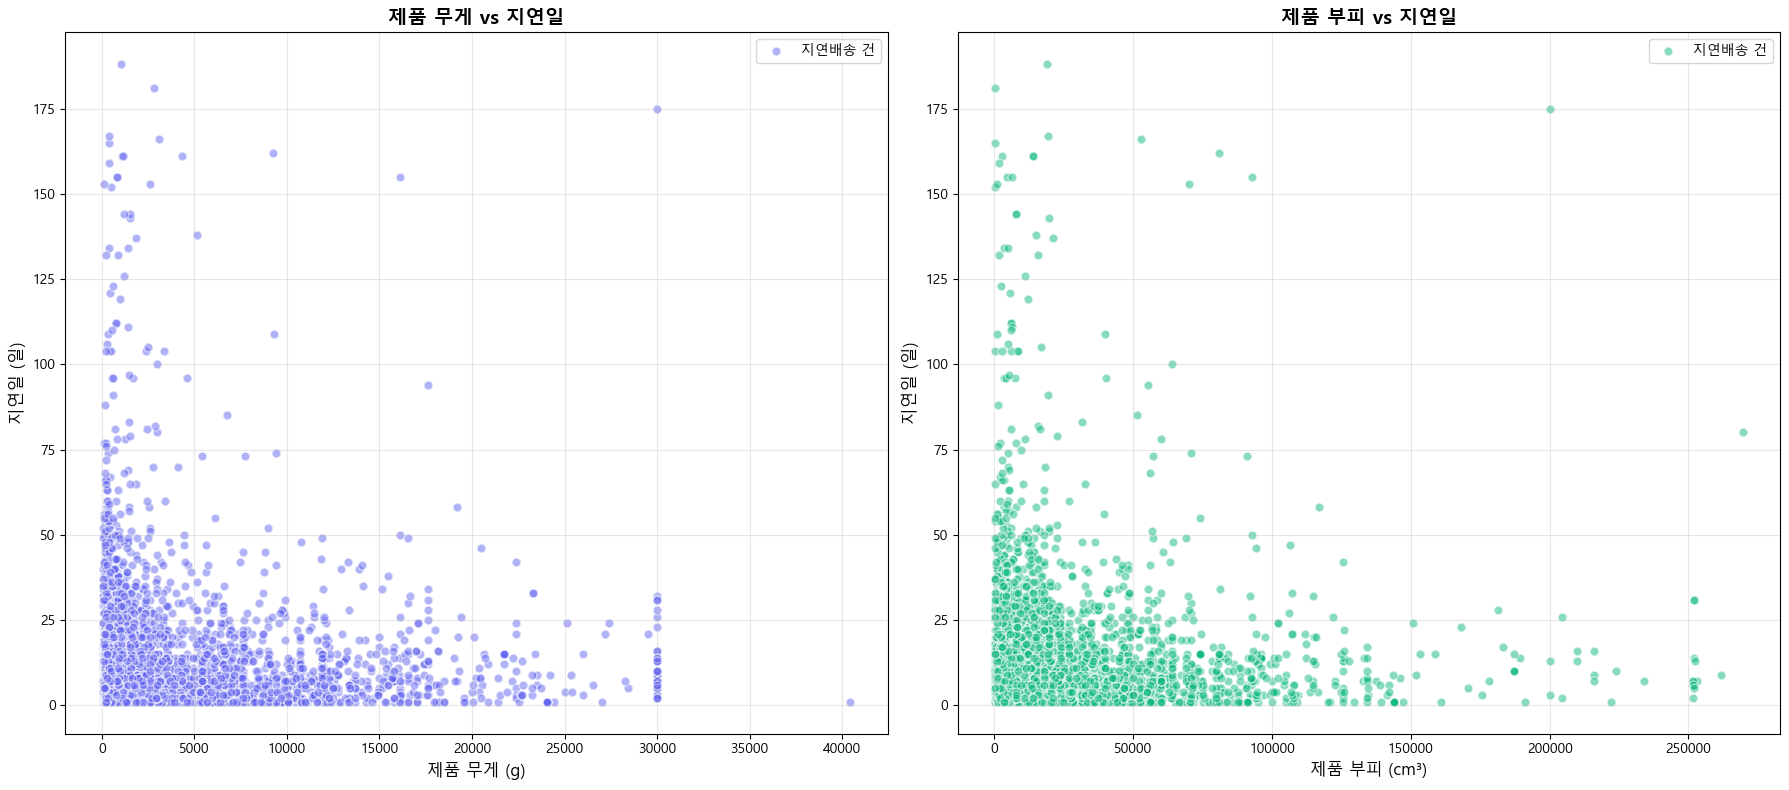

In [228]:
# 시각화
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))

y_delay = df_product['delivery_delay_days']
x_weight = df_product['product_weight_g']
x_volume = df_product['product_volume_cm3']

# 제품 무게 vs 지연일 
axes[0].scatter(x_weight, y_delay, color='#6366F1', alpha=0.5, s=40, edgecolors='white', label='지연배송 건')

axes[0].set_xlabel('제품 무게 (g)', fontsize=12)
axes[0].set_ylabel('지연일 (일)', fontsize=12)
axes[0].set_title('제품 무게 vs 지연일', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# 제품 부피 vs 지연일
axes[1].scatter(x_volume, y_delay, color='#10B981', alpha=0.5, s=40, edgecolors='white', label='지연배송 건')

axes[1].set_xlabel('제품 부피 (cm³)', fontsize=12)
axes[1].set_ylabel('지연일 (일)', fontsize=12)
axes[1].set_title('제품 부피 vs 지연일', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

# 레이아웃 정리 및 출력
plt.tight_layout()
plt.show()

In [229]:
# 상관관계 분석할 3개 컬럼만 선택
cols_to_corr = ['product_weight_g', 'product_volume_cm3', 'delivery_delay_days']
df_corr_data = df_product[cols_to_corr]

y_delay = df_corr_data['delivery_delay_days']
x_weight = df_corr_data['product_weight_g']
x_volume = df_corr_data['product_volume_cm3']

# 피어슨 상관계수
print("[Pearson 상관계수]")
r_pearson_w, p_pearson_w = stats.pearsonr(x_weight, y_delay)
r_pearson_v, p_pearson_v = stats.pearsonr(x_volume, y_delay)

print(f"무게 vs 지연일: 상관계수(r) = {r_pearson_w:.3f}, p-value = {p_pearson_w:3f}")
print(f"결정계수 = {r_pearson_w**2:.4f}")

print(f"\n부피 vs 지연일: 상관계수(r) = {r_pearson_v:.3f}, p-value = {p_pearson_v:3f}")
print(f"결정계수 = {r_pearson_v**2:.4f}")


print('-'*60)

# 스피어만 상관계수
print("[Spearman 상관계수]")
r_spearman_w, p_spearman_w = stats.spearmanr(x_weight, y_delay)
r_spearman_v, p_spearman_v = stats.spearmanr(x_volume, y_delay)

print(f"무게 vs 지연일: 상관계수(r) = {r_spearman_w:.3f}, p-value = {p_spearman_w:3f}")
print(f"부피 vs 지연일: 상관계수(r) = {r_spearman_v:.3f}, p-value = {p_spearman_v:3f}")



[Pearson 상관계수]
무게 vs 지연일: 상관계수(r) = 0.020, p-value = 0.091298
결정계수 = 0.0004

부피 vs 지연일: 상관계수(r) = 0.029, p-value = 0.012989
결정계수 = 0.0009
------------------------------------------------------------
[Spearman 상관계수]
무게 vs 지연일: 상관계수(r) = 0.028, p-value = 0.016749
부피 vs 지연일: 상관계수(r) = 0.041, p-value = 0.000440


- 무게와 부피는 지연일에 관련이 없다.

### 카테고리 시작

In [230]:
df_product['product_category_name_english'].value_counts().sort_values(ascending=False)

product_category_name_english
bed_bath_table                             768
health_beauty                              715
furniture_decor                            573
sports_leisure                             532
computers_accessories                      496
watches_gifts                              422
housewares                                 340
telephony                                  307
auto                                       291
garden_tools                               280
toys                                       256
baby                                       228
cool_stuff                                 217
perfumery                                  216
electronics                                207
stationery                                 167
office_furniture                           133
unknown                                    116
fashion_bags_accessories                   105
pet_shop                                    95
consoles_games                

- 각 카테고리의 평균 지연일이 차이가 날까? => ANOVA(분산분석)
### 
| 정규성 확인             | 등분산 확인 | 검정 방법              | 사후검정               | 효과크기                        |
|:------------------------:|:-----------:|:----------------------:|:----------------------:|:-------------------------------:|
| Q-Q Plot + Shapiro-Wilk | Levene      | One-way ANOVA          | Tukey HSD              | η² / ω²                        |
| Q-Q Plot + Shapiro-Wilk | Levene (위반) | Welch's ANOVA        | Games-Howell           | η² / ω²                        |
| 정규성 위반              | —           | Kruskal-Wallis         | Dunn 검정              | η²_H                           |

> **정규성 위반 시** 비모수 검정(Kruskal-Wallis)을 사용하며, 이 경우 등분산 확인은 불필요합니다.
>
> **등분산성 위반은 CLT와 무관합니다** — 정규성은 대표본에서 CLT로 완화되지만, 등분산성은 표본 크기와 관계없이 Levene 위반 시 항상 Welch's ANOVA를 사용합니다.


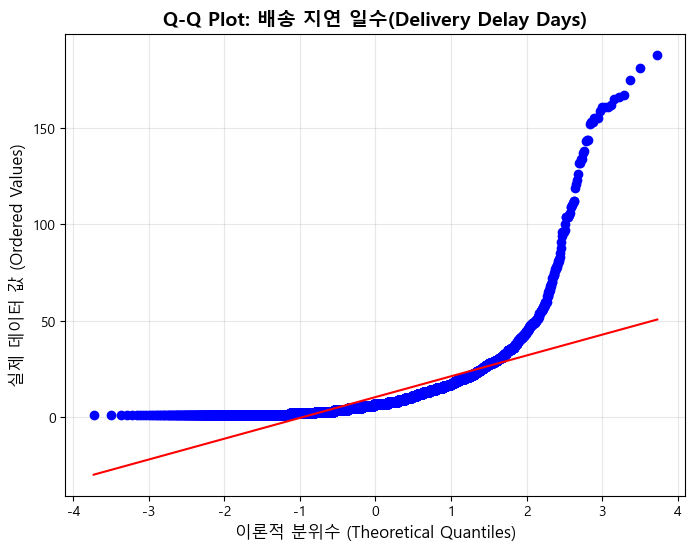


 [Shapiro-Wilk 정규성 검정 결과]
- 검정 통계량(W): 0.5527
- p-value: 8.555e-87
결론: 유의수준 0.05 하에서 정규분포를 따르지 않는다 (정규성 가정 위배)


In [231]:
# 정규성 

# Q-Q plot
plt.figure(figsize=(8, 6))
stats.probplot(df_product['delivery_delay_days'], dist="norm", plot=plt)

plt.title('Q-Q Plot: 배송 지연 일수(Delivery Delay Days)', fontsize=14, fontweight='bold')
plt.xlabel('이론적 분위수 (Theoretical Quantiles)', fontsize=12)
plt.ylabel('실제 데이터 값 (Ordered Values)', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

# Shapiro-Wilk 검정
stat_shapiro, p_shapiro = stats.shapiro(df_product['delivery_delay_days'])

print("\n [Shapiro-Wilk 정규성 검정 결과]")
print(f"- 검정 통계량(W): {stat_shapiro:.4f}")
print(f"- p-value: {p_shapiro:.3e}")

if p_shapiro < 0.05:
    print("결론: 유의수준 0.05 하에서 정규분포를 따르지 않는다 (정규성 가정 위배)")
else:
    print("결론: 유의수준 0.05 하에서 정규분포를 따른다 (정규성 가정 만족)")

- 정규성 위배

In [ ]:
#Kruskal-Wallis 검정

groups = [group['delivery_delay_days'].values for name, group in df_product.groupby('product_category_name_english')]
h_stat, p_kruskal = stats.kruskal(*groups)

print("[Kruskal-Wallis 검정 결과]")
print(f"- 통계량(H): {h_stat:.4f}")
print(f"- p-value: {p_kruskal:.3e}\n")

if p_kruskal < 0.05:
    print("대립가설 채택")
    print("결론: 카테고리에 따라 배송 지연 일수에 통계적으로 유의미한 차이가 있다")
else:
    print("귀무가설 채택")
    print("결론: 카테고리에 따라 배송 지연 일수에 통계적으로 유의미한 차이가 있지않다.")

[Kruskal-Wallis 검정 결과]
- 통계량(H): 115.3608
- p-value: 1.208e-04

대립가설 채택
결론: 카테고리에 따라 배송 지연 일수에 통계적으로 유의미한 차이가 있다


In [ ]:
# 사후검정(Dunn검정)

dunn_matrix = sp.posthoc_dunn(
    df_product, 
    val_col='delivery_delay_days', 
    group_col='product_category_name_english', 
    p_adjust='bonferroni'
)

dunn_matrix.head()

,agro_industry_and_commerce,air_conditioning,art,arts_and_craftmanship,audio,auto,baby,bed_bath_table,books_general_interest,books_imported,books_technical,christmas_supplies,cine_photo,computers,computers_accessories,consoles_games,construction_tools_construction,construction_tools_lights,construction_tools_safety,cool_stuff,costruction_tools_garden,costruction_tools_tools,drinks,dvds_blu_ray,electronics,fashio_female_clothing,fashion_bags_accessories,fashion_male_clothing,fashion_shoes,fashion_sport,fashion_underwear_beach,fixed_telephony,flowers,food,food_drink,furniture_bedroom,furniture_decor,furniture_living_room,furniture_mattress_and_upholstery,garden_tools,health_beauty,home_appliances,home_appliances_2,home_comfort_2,home_confort,home_construction,housewares,industry_commerce_and_business,kitchen_dining_laundry_garden_furniture,luggage_accessories,market_place,music,musical_instruments,office_furniture,perfumery,pet_shop,signaling_and_security,small_appliances,small_appliances_home_oven_and_coffee,sports_leisure,stationery,tablets_printing_image,telephony,toys,unknown,watches_gifts
agro_industry_and_commerce,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
air_conditioning,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
art,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.530125,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.436991,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
arts_and_craftmanship,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
audio,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
# 결과가 너무 많아서 p < 0.05 짝꿍들만 필터링

# 표(리스트) 형태로 펼치기.
dunn_unstacked = dunn_matrix.unstack().reset_index()
dunn_unstacked.columns = ['Category_1', 'Category_2', 'p_value']

# 자기 자신과의 비교 제거, p < 0.05 인 것만 남기기
significant_pairs = dunn_unstacked[
    (dunn_unstacked['Category_1'] != dunn_unstacked['Category_2']) & 
    (dunn_unstacked['p_value'] < 0.05)
]

# 3. 결과 정렬 및 출력
significant_pairs = significant_pairs.sort_values('p_value')
significant_pairs

,Category_1,Category_2,p_value
